In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [6]:
path = "../../data/processed/telecom_encoding.csv"
df = pd.read_csv(path)

print("shape:", df.shape)
print(df.head())
print(df.dtypes)
print('df.size:', df.size)

# 데이터 정렬 (id, year 기준)
df = df.sort_values(["id", "year"]).reset_index(drop=True)

shape: (70145, 35)
      id  gender  age  year  school  mobile_bundle  income  job  \
0  10001       0   51  2018       4              1       0    0   
1  10001       0   52  2019       4              1      10    1   
2  10001       0   53  2020       4              1      10    1   
3  10001       0   54  2021       4              1       9    1   
4  10001       0   55  2022       4              1       8    1   

   phone_usage_per_m  telecom_change_yn  ...  jeonbuk  jeonnam  gyeongbuk  \
0                 45                  1  ...        0        0          0   
1                 75                  1  ...        0        0          0   
2                 41                  1  ...        0        0          0   
3                 32                  0  ...        0        0          0   
4                 51                  0  ...        0        0          0   

   gyeongnam  jeju  sejong  skt  kt  lgu  mvno  
0          0     0       0    0   1    0     0  
1          0     

In [7]:
# # churn_status_2 문자열에 'churned' 포함 → 이탈(1)
# df["y_churn"] = df["churn_status_2"].astype(str).str.contains("churned", case=False, na=False).astype(int)

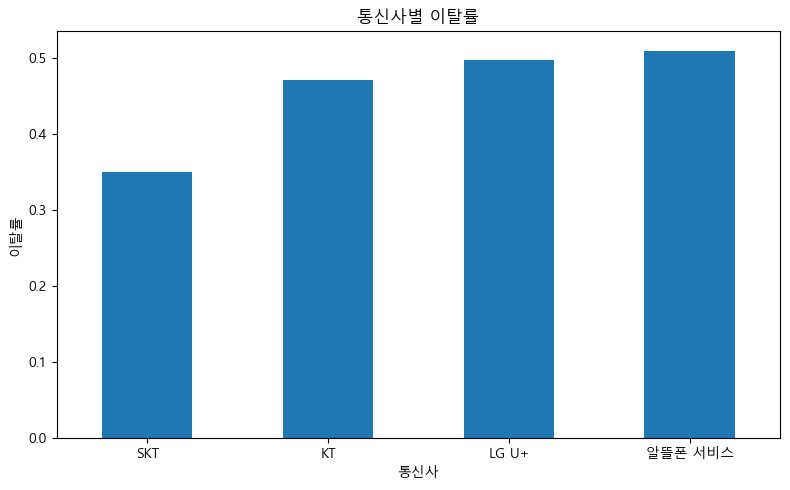

In [8]:
# 1. 원-핫 인코딩된 컬럼들을 다시 하나의 'telecom_label'로 통합
# 각 행에서 값이 1인 컬럼의 이름을 가져옵니다.
carrier_cols = ['skt', 'kt', 'lgu', 'mvno']
df['telecom_label'] = df[carrier_cols].idxmax(axis=1)

# 2. 보기 좋게 이름을 한글/대문자로 매핑 (기존 telecom_map 역할)
rename_map = {
    'skt': 'SKT',
    'kt': 'KT',
    'lgu': 'LG U+',
    'mvno': '알뜰폰 서비스'
}
df['telecom_label'] = df['telecom_label'].map(rename_map)

# 3. 통신사별 이탈률 계산 (기존 컬럼명 telecom_change_yn 사용)
telecom_churn = df.groupby("telecom_label")["telecom_change_yn"].mean().sort_values()
# 4. 그래프 시각화 (기존 코드와 동일)
plt.figure(figsize=(8, 5))
telecom_churn.plot(kind="bar")
plt.title("통신사별 이탈률")
plt.xlabel("통신사")
plt.ylabel("이탈률")
plt.xticks(rotation=0) # 글자 겹침 방지
plt.tight_layout()
plt.show()

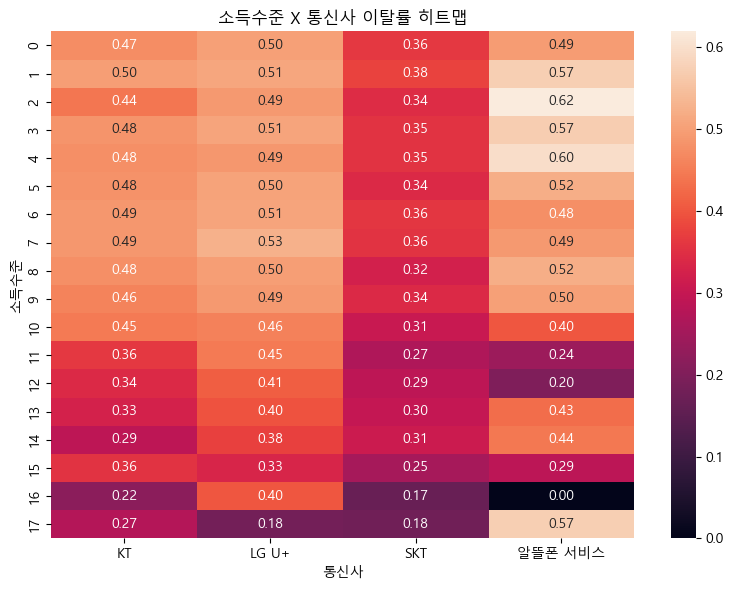

<Figure size 1000x500 with 0 Axes>

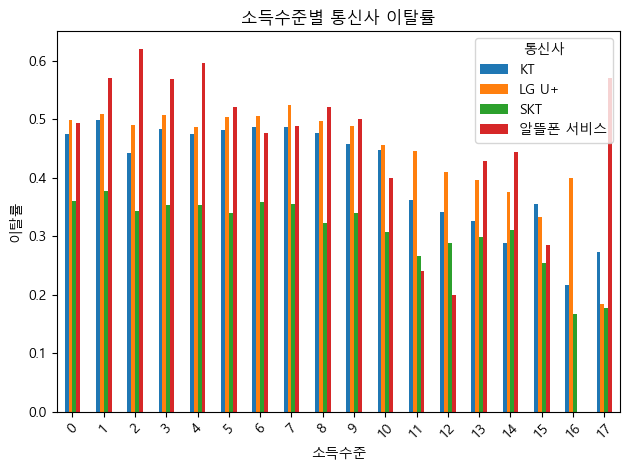

In [9]:
# [개인정보] 개인 월평균 소득
#   1	소득 없음
# 	2	50만 원 미만
# 	3	500100만 원 미만
# 	4	1000150만 원 미만
# 	5	1500200만 원 미만
# 	6	2000250만 원 미만
# 	7	2500300만 원 미만
# 	8	3000350만 원 미만
# 	9	3500400만 원 미만
# 	10	4000450만 원 미만
# 	11	4500500만 원 미만
# 	12	5000550만 원 미만
# 	13	5500600만 원 미만
# 	14	6000650만 원 미만
# 	15	6500700만 원 미만
# 	16	7000750만 원 미만
# 	17	7500800만 원 미만
# 	18	800만 원 이상
pivot_income = df.pivot_table(
    index="income",
    columns="telecom_label",
    values="telecom_change_yn",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_income,
    annot=True,
    fmt=".2f"
)

plt.title("소득수준 X 통신사 이탈률 히트맵")
plt.xlabel("통신사")
plt.ylabel("소득수준")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

pivot_income.plot(kind="bar")

plt.title("소득수준별 통신사 이탈률")
plt.xlabel("소득수준")
plt.ylabel("이탈률")

plt.xticks(rotation=45)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

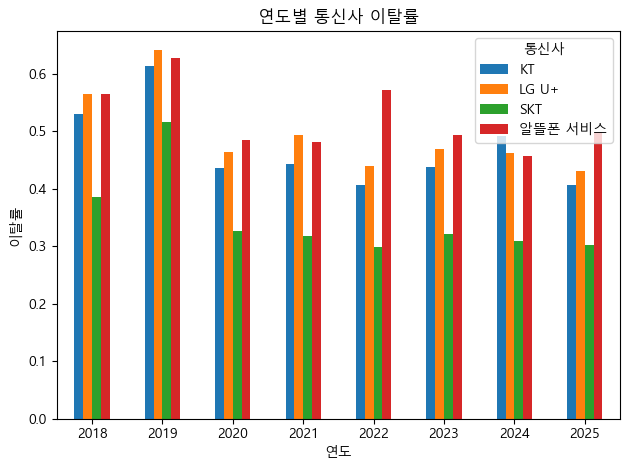

In [10]:
pivot_year = df.pivot_table(
    index="year",
    columns="telecom_label",
    values="telecom_change_yn",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(10,5))

pivot_year.plot(kind="bar")

plt.title("연도별 통신사 이탈률")
plt.xlabel("연도")
plt.ylabel("이탈률")

plt.xticks(rotation=0)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

In [11]:
print(df["year"].value_counts().sort_index())
print(df[df["year"]==2017].shape)
print(df[df["year"]==2017]["telecom_change_yn"].isna().sum())

year
2018    7747
2019    9377
2020    9155
2021    9239
2022    9213
2023    9151
2024    8226
2025    8037
Name: count, dtype: int64
(0, 36)
0


In [12]:

# heat_cols = [
#     "gender",
#     "birth_year",
#     "mar",
#     "income",
#     "job",
#     "region",
#     "phone_usage_per_m",
#     "mobile_bundle",
#     "telecom",
#     "telecom_change_yn"
# ]

# heat_df = df[heat_cols]

# # 상관관계 계산
# corr = heat_df.corr(numeric_only=True)

# plt.figure(figsize=(10,8))

# sns.heatmap(
#     corr,
#     annot=True,
#     fmt=".2f",
#     square=True
# )

# plt.title("통신사 이탈 영향 피처 상관관계 히트맵")

# plt.tight_layout()
# plt.show()

In [13]:
df.head()

,id,gender,age,year,school,mobile_bundle,income,job,phone_usage_per_m,telecom_change_yn,...,jeonnam,gyeongbuk,gyeongnam,jeju,sejong,skt,kt,lgu,mvno,telecom_label
0,10001,0,51,2018,4,1,0,0,45,1,...,0,0,0,0,0,0,1,0,0,KT
1,10001,0,52,2019,4,1,10,1,75,1,...,0,0,0,0,0,1,0,0,0,SKT
2,10001,0,53,2020,4,1,10,1,41,1,...,0,0,0,0,0,0,1,0,0,KT
3,10001,0,54,2021,4,1,9,1,32,0,...,0,0,0,0,0,0,1,0,0,KT
4,10001,0,55,2022,4,1,8,1,51,0,...,0,0,0,0,0,0,1,0,0,KT


C:\Users\Playdata\AppData\Local\Temp\ipykernel_37584\2238546542.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


<Figure size 900x500 with 0 Axes>

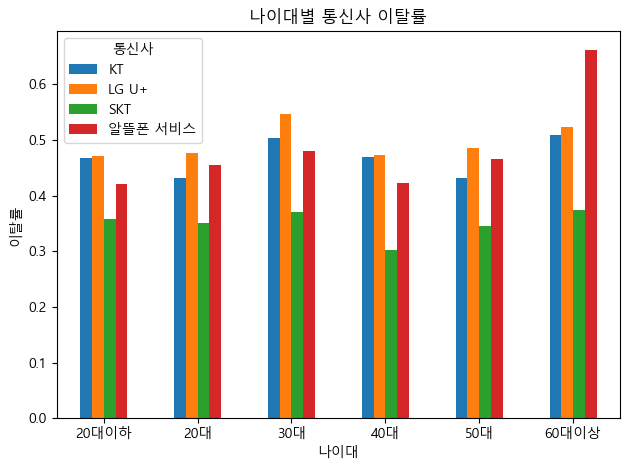

In [14]:
# 나이 계산
# df["age"] = df["year"] - df["birth_year"]

bins = [0,20,30,40,50,60,100]
labels = ["20대이하","20대","30대","40대","50대","60대이상"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# telecom_map = {
#     1:"SKT",
#     2:"KT",
#     3:"LG U+",
#     4:"알뜰폰 서비스"
# }
# df["telecom_label"] = df["telecom"].map(telecom_map)

pivot = df.pivot_table(
    index="age_group",
    columns="telecom_label",
    values="telecom_change_yn",
    aggfunc="mean"
)

# 그래프
plt.figure(figsize=(9,5))
pivot.plot(kind="bar")

plt.title("나이대별 통신사 이탈률")
plt.xlabel("나이대")
plt.ylabel("이탈률")

plt.xticks(rotation=0)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_37584\1019685701.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


<Figure size 1200x600 with 0 Axes>

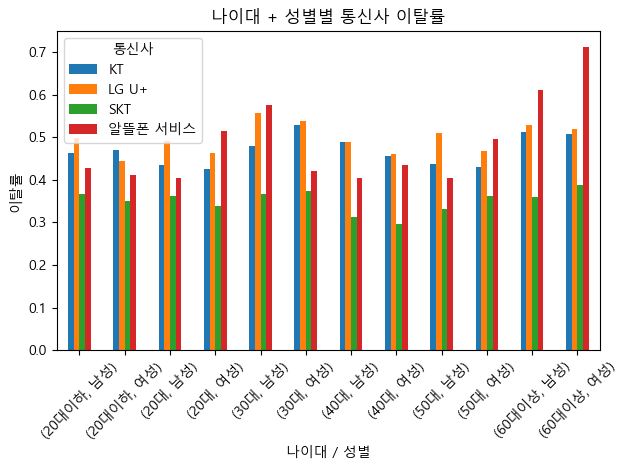

In [15]:
gender_map = {
    0: "남성",
    1: "여성"
}

df["gender_label"] = df["gender"].map(gender_map)

pivot = df.pivot_table(
    index=["age_group","gender_label"],
    columns="telecom_label",
    values="telecom_change_yn",
    aggfunc="mean"
)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,6))

pivot.plot(kind="bar")

plt.title("나이대 + 성별별 통신사 이탈률")
plt.xlabel("나이대 / 성별")
plt.ylabel("이탈률")

plt.xticks(rotation=45)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

In [16]:
df["income"].value_counts().sort_index()

income
0     22797
1      3254
2      3632
3      3716
4      6766
5      7156
6      7998
7      4856
8      3978
9      1893
10     1556
11     1128
12      468
13      267
14      183
15      125
16       75
17      297
Name: count, dtype: int64

In [17]:
df.count()

id                   70145
gender               70145
age                  70145
year                 70145
school               70145
mobile_bundle        70145
income               70145
job                  70145
phone_usage_per_m    70145
telecom_change_yn    70145
mar_1                70145
mar_2                70145
mar_3                70145
mar_4                70145
seoul                70145
busan                70145
daegu                70145
incheon              70145
gwangju              70145
daejeon              70145
ulsan                70145
gyeonggi             70145
gangwon              70145
chungbuk             70145
chungnam             70145
jeonbuk              70145
jeonnam              70145
gyeongbuk            70145
gyeongnam            70145
jeju                 70145
sejong               70145
skt                  70145
kt                   70145
lgu                  70145
mvno                 70145
telecom_label        70145
age_group            70143
g

<Figure size 1000x500 with 0 Axes>

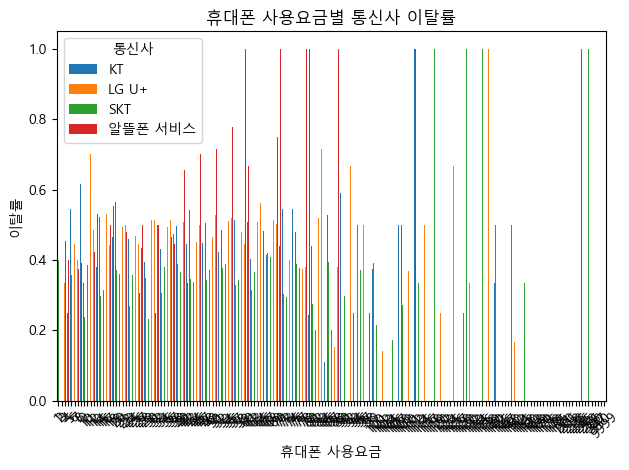

In [18]:
# 휴대폰 사용요금 기준 eda
# [방송통신 서비스 가입 및 지출 현황] 월평균 휴대폰 이용 총 금액(리코드)
#   1	1만원 미만
# 	2	1만원 이상 0 2만원 미만
# 	3	2만원 이상 0 3만원 미만
# 	4	3만원 이상 0 4만원 미만
# 	5	4만원 이상 0 5만원 미만
# 	6	5만원 이상 0 6만원 미만
# 	7	6만원 이상 0 7만원 미만
# 	8	7만원 이상 0 8만원 미만
# 	9	8만원 이상 0 9만원 미만
# 	10	9만원 이상 0 10만원 미만
# 	11	10만원 이상
# 	9999	모름/무응답

pivot_income = df.pivot_table(
    index="phone_usage_per_m",
    columns="telecom_label",
    values="telecom_change_yn",
    aggfunc="mean"
)

plt.figure(figsize=(10,5))

pivot_income.plot(kind="bar")

plt.title("휴대폰 사용요금별 통신사 이탈률")
plt.xlabel("휴대폰 사용요금")
plt.ylabel("이탈률")

plt.xticks(rotation=45)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()